In [ ]:
pip install deepinv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 986.9/986.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.1 MB/s eta 0:00:00


In [ ]:
import deepinv as dinv
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import numpy as np

In [ ]:
def build_SPC_physics(rate: float, img_size: tuple[int], noise_lvl: float, ordering: str, device: torch.device):

    m = int(rate*img_size[1]*img_size[2])
    physics = dinv.physics.SinglePixelCamera(
        m=m,
        img_size=img_size,
        noise_model=dinv.physics.GaussianNoise(sigma=noise_lvl),
        device=device,
        ordering=ordering,
    )

    return physics

from deepinv.physics.blur import gaussian_blur

def build_blur_physics(n: int, sigma_noise: float, blur_sigma: float, grayscale: bool, device: torch.device):
    channels = 1 if grayscale else 3
    blur_filter = gaussian_blur(sigma=blur_sigma).to(device)
    if blur_filter.shape[1] == 1 and channels > 1:
        blur_filter = blur_filter.repeat(1, channels, 1, 1)
    physics = dinv.physics.BlurFFT(
        img_size=(channels, n, n),
        filter=blur_filter,
        device=device,
        noise_model=dinv.physics.GaussianNoise(sigma=sigma_noise),
    )
    return physics

def build_Inpainting_physics(keep_rate: float, img_size: tuple[int], noise_lvl: float, device: torch.device):
    # 1. Crear una máscara del tamaño de la imagen llena de unos
    mask = torch.ones(img_size).to(device)

    # 2. Generar ruido uniforme del mismo tamaño y crear la máscara binaria
    # Si el valor aleatorio es menor a keep_rate, el píxel se queda (1), si no, se borra (0)
    mask = (torch.rand_like(mask) < keep_rate).float()

    # Definir la física de Inpainting
    physics = dinv.physics.Inpainting(
        mask=mask,
        tensor_size=img_size,
        noise_model=dinv.physics.GaussianNoise(sigma=noise_lvl),
        device=device
    )
    return physics

In [ ]:
def set_seed(seed: int):
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # torch.use_deterministic_algorithms(mode=True)

In [ ]:
class PGDStep(dinv.models.Reconstructor):
    def __init__(self, data_fidelity, prior, stepsize, lambd):
        super().__init__()
        self.data_fidelity = data_fidelity
        self.prior = prior
        self.stepsize = stepsize
        self.lambd = lambd

    def step(self, x_k, y, physics, **kwargs):
        """Algorithm PGD Step.

        :param torch.Tensor x_k: reconstruction at k
        :param torch.Tensor y: measurements.
        :param dinv.physics.Physics physics: measurement operator.
        :return: torch.Tensor: reconstructed image.
        """
        u = x_k - self.stepsize * self.data_fidelity.grad(
            x_k, y, physics
        )  # Gradient step
        x_k = self.prior.prox(
            u, sigma_denoiser=self.lambd * self.stepsize
        )  # Proximal step with denoiser

        return x_k

In [ ]:
class ADMMStep(dinv.models.Reconstructor):
    def __init__(self, data_fidelity, prior, rho_admm, lambd):
        super().__init__()
        self.data_fidelity = data_fidelity
        self.prior = prior
        self.rho_admm = rho_admm
        self.lambd = lambd

    def step(self, z_k, x_k, u_k, y, physics):

        z_next = self.prior.prox(x_k+u_k, sigma_denoiser=self.lambd)

        x_next = self.data_fidelity.prox(z_next-u_k, y, physics, gamma= 1.0/self.rho_admm)

        u_next = u_k + x_next - z_next

        return z_next, x_next, u_next

In [ ]:
import torch

class AccStep():
  """
  Class to apply different acceleration schemes
  about a base operator (e.g. PGDStep.step).
  """

  def __init__(self, rho=0.9, max_m=5):
    self.rho = rho
    self.max_m = max_m  # Memoria máxima para no saturar RAM
    self.reset()

  def reset(self):
    # To FISTA
    self.t = 1.0

    # Internal States
    self.x_prev = None      # x_{k} (entrada al operador)
    self.z_prev = None      # z_{k} (salida acelerada)

    # To Anderson
    self.x_hist = []        # g(x_k)'s history
    self.f_hist = []      # r_k's history

  def step(self, x_next, action):
    """
    x_next: resultado del operador g(x_prev)
    action: esquema de aceleración
    """
    # History
    if self.x_prev is not None:
      # Residual r_k = g(x_k) - x_k
      res = (x_next - self.x_prev).detach()

      self.x_hist.append(x_next.detach())
      self.f_hist.append(res)

      # Keep the history of len m
      if len(self.x_hist) > self.max_m:
        self.x_hist.pop(0)
        self.f_hist.pop(0)

    # Select the accelerator
    if action == 0:
      z_next = self._no_accel(x_next)

    elif action == 1:
      z_next = self._fista_classic(x_next)

    elif action == 2:
      z_next = self._fixed_momentum(x_next)

    elif action in [3, 4, 5]:
      m = action
      z_next = self._anderson_math(x_next, m)

    else:
      raise ValueError("Unknown action")

    # Update x & z
    self.x_prev = z_next.detach()
    self.z_prev = z_next.detach()

    return z_next

  # --------------------------
  # Actions
  # --------------------------

  def _no_accel(self, x_next):
    return x_next

  def _fista_classic(self, x_next):
    if self.z_prev is None:
      return x_next

    t_new = 0.5 * (1.0 + (1.0 + 4.0 * self.t**2) ** 0.5)
    beta = (self.t - 1.0) / t_new

    # z_{k+1} = x_{k+1} + beta * (x_{k+1} - x_k)
    z_next = x_next + beta * (x_next - self.x_prev)

    self.t = t_new
    return z_next

  def _fixed_momentum(self, x_next):
    if self.x_prev is None:
      return x_next

    z_next = x_next + self.rho * (x_next - self.x_prev)
    return z_next

  def _anderson_math(self, x_next, m):
    """
    Compute Anderson Acceleration with memory (m).
    """
    k = len(self.f_hist)

    # We need at least 2 samples.
    if k < 2:
      return x_next

    # Use the last m elements
    actual_m = min(k, m)
    f_samples = self.f_hist[-actual_m:]
    x_samples = self.x_hist[-actual_m:]

    # Build matrices
    R = torch.stack([ri.reshape(-1) for ri in f_samples], dim=1)
    X = torch.stack([xi.reshape(-1) for xi in x_samples], dim=1)

    device = x_next.device
    n_cols = R.shape[1]

    # System KKT: min ||R @ alpha||^2 s.t. sum(alpha) = 1
    G = R.t() @ R
    G += torch.eye(n_cols, device=device) * 1e-6  # Reg to stability

    KKT = torch.zeros((n_cols + 1, n_cols + 1), device=device)
    KKT[:n_cols, :n_cols] = G
    KKT[:n_cols, n_cols] = 1.0
    KKT[n_cols, :n_cols] = 1.0

    rhs = torch.zeros(n_cols + 1, device=device)
    rhs[n_cols] = 1.0

    try:
      sol = torch.linalg.solve(KKT, rhs)
      alpha = sol[:n_cols]
      # linear combination of the operator's outputs
      z_next = (X @ alpha).reshape_as(x_next)
    except RuntimeError:
      # If solver fails, return without accelerating
      z_next = x_next

    return z_next

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
set_seed(seed=0)

metric = dinv.metric.PSNR()

physics = build_SPC_physics(0.3, (3, 256, 256), 0.0, "zig_zag", device)
# physics = build_Inpainting_physics(keep_rate=0.2, img_size=(3, 256, 256), noise_lvl=0.01, device=device)
# physics = build_blur_physics(256, 0.1, 1.5, False, device)

x = dinv.utils.load_example("butterfly.png", device=device)
print(x.shape)

y = physics(x)
print(y.shape)

x0 = physics.A_adjoint(y)

Using device: cuda
torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


In [ ]:
# Reconstruction Algorithm

data_fidelity = dinv.optim.L2()
denoiser = dinv.models.DnCNN(device=device, pretrained="download_lipschitz")
prior = dinv.optim.PnP(denoiser=denoiser)
stepsize = 0.1 / physics.compute_norm(physics.A_adjoint(y), tol=1e-3).item()
_lambda = 0.1
rho_admm = 0.01
max_iter = 500

# --- Experiment ---
actions_to_test = [0, 1, 2, 3, 4, 5]
action_labels = {
    0: "No acc", 1: "FISTA", 2: "Momentum", 3: "AA (m=3)", 4: "AA (m=4)", 5: "AA (m=5)"
    }

admm_step = ADMMStep(data_fidelity=data_fidelity, prior=prior, rho_admm=rho_admm, lambd=_lambda)

actions = [0, 1, 2, 3, 4, 5]
all_results = {} # Log PSNR or curves here

with torch.inference_mode():
    for act_z in actions:
        for act_x in actions:
            for act_u in actions:
                idx = (act_z, act_x, act_u)
                combo_name = f"Z:{action_labels[act_z]} | X:{action_labels[act_x]} | U: {action_labels[act_u]}"
                x_k = x0.clone()
                z_k = x0.clone()
                u_k = torch.zeros_like(x0)

                # Aceleradores independientes
                acc_z = AccStep(rho=0.9, max_m=5)
                acc_x = AccStep(rho=0.9, max_m=5)
                acc_u = AccStep(rho=0.9, max_m=5)

                psnr_curve = []

                for k in tqdm(range(max_iter), colour='magenta'):

                    z_next, x_next, u_next = admm_step.step(z_k=z_k, x_k=x_k, u_k=u_k, y=y, physics=physics)

                    z_next = acc_z.step(z_next, act_z)
                    x_next = acc_x.step(x_next, act_x)
                    u_next = acc_u.step(u_next, act_u)

                    z_k, x_k, u_k = z_next, x_next, u_next

                    # Métrica
                    psnr_curve.append(metric(x_k, x).item())

                all_results[idx] = psnr_curve
                print(f"Finalizado: {combo_name} - PSNR Final: {psnr_curve[-1]:.4f}")
            print(f'keys: {all_results.keys()}')

Power iteration converged at iteration 2, ||A^T A||_2=1.00


100%|██████████| 500/500 [00:11<00:00, 44.92it/s]


Finalizado: Z:No acc | X:No acc | U: No acc - PSNR Final: 30.9925


100%|██████████| 500/500 [00:11<00:00, 43.74it/s]


Finalizado: Z:No acc | X:No acc | U: FISTA - PSNR Final: 30.9925


...

Finalizado: Z:AA (m=5) | X:AA (m=5) | U: AA (m=3) - PSNR Final: 30.9981


100%|██████████| 500/500 [00:12<00:00, 39.09it/s]


Finalizado: Z:AA (m=5) | X:AA (m=5) | U: AA (m=4) - PSNR Final: 30.9942


100%|██████████| 500/500 [00:12<00:00, 38.83it/s]

Finalizado: Z:AA (m=5) | X:AA (m=5) | U: AA (m=5) - PSNR Final: 30.9896
keys: dict_keys([(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 2, 5), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 3, 5), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (0, 4, 5), (0, 5, 0), (0, 5, 1), (0, 5, 2), (0, 5, 3), (0, 5, 4), (0, 5, 5), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 0, 4), (1, 0, 5), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 1, 4), (1, 1, 5), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (1, 2, 4), (1, 2, 5), (1, 3, 0), (1, 3, 1), (1, 3, 2), (1, 3, 3), (1, 3, 4), (1, 3, 5), (1, 4, 0), (1, 4, 1), (1, 4, 2), (1, 4, 3), (1, 4, 4), (1, 4, 5), (1, 5, 0), (1, 5, 1), (1, 5, 2), (1, 5, 3), (1, 5, 4), (1, 5, 5), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 0, 4), (2, 0, 5), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 1, 4)

In [ ]:
import numpy as np

def guardar_resultados_numpy(all_results, filename="resultados_admm.npz"):
    # Convertimos las llaves (z,x,u) a strings para que sean compatibles
    data_to_save = {str(k): v for k, v in all_results.items()}
    np.savez_compressed(filename, **data_to_save)
    print(f"Resultados guardados en {filename}")

def cargar_resultados_numpy(filename="resultados_admm.npz"):
    with np.load(filename) as data:
        # Reconstruimos el diccionario convirtiendo las llaves de nuevo a tuplas
        results = {eval(k): data[k] for k in data.files}
    return results

# Uso:
guardar_resultados_numpy(all_results)
# all_results_recuperado = cargar_resultados_numpy()

Resultados guardados en resultados_admm.npz


In [ ]:
all_results.keys()

dict_keys([(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 2, 5), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 3, 5), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (0, 4, 5), (0, 5, 0), (0, 5, 1), (0, 5, 2), (0, 5, 3), (0, 5, 4), (0, 5, 5), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 0, 4), (1, 0, 5), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 1, 4), (1, 1, 5), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (1, 2, 4), (1, 2, 5), (1, 3, 0), (1, 3, 1), (1, 3, 2), (1, 3, 3), (1, 3, 4), (1, 3, 5), (1, 4, 0), (1, 4, 1), (1, 4, 2), (1, 4, 3), (1, 4, 4), (1, 4, 5), (1, 5, 0), (1, 5, 1), (1, 5, 2), (1, 5, 3), (1, 5, 4), (1, 5, 5), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 0, 4), (2, 0, 5), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 1, 4), (2, 1, 5), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (2, 2, 4), (2, 2, 5),

/tmp/ipykernel_3080/37539798.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(all_results))


Z:No Acc | X:No Acc | U:No Acc
Z:No Acc | X:No Acc | U:FISTA
Z:No Acc | X:No Acc | U:Momentum
Z:No Acc | X:No Acc | U:AA (m=3)
Z:No Acc | X:No Acc | U:AA (m=4)
Z:No Acc | X:No Acc | U:AA (m=5)
Z:No Acc | X:FISTA | U:No Acc
Z:No Acc | X:FISTA | U:FISTA
Z:No Acc | X:FISTA | U:Momentum
Z:No Acc | X:FISTA | U:AA (m=3)
Z:No Acc | X:FISTA | U:AA (m=4)
Z:No Acc | X:FISTA | U:AA (m=5)
Z:No Acc | X:Momentum | U:No Acc
Z:No Acc | X:Momentum | U:FISTA
Z:No Acc | X:Momentum | U:Momentum
Z:No Acc | X:Momentum | U:AA (m=3)
Z:No Acc | X:Momentum | U:AA (m=4)
Z:No Acc | X:Momentum | U:AA (m=5)
Z:No Acc | X:AA (m=3) | U:No Acc
Z:No Acc | X:AA (m=3) | U:FISTA
Z:No Acc | X:AA (m=3) | U:Momentum
Z:No Acc | X:AA (m=3) | U:AA (m=3)
Z:No Acc | X:AA (m=3) | U:AA (m=4)
Z:No Acc | X:AA (m=3) | U:AA (m=5)
Z:No Acc | X:AA (m=4) | U:No Acc
Z:No Acc | X:AA (m=4) | U:FISTA
Z:No Acc | X:AA (m=4) | U:Momentum
Z:No Acc | X:AA (m=4) | U:AA (m=3)
Z:No Acc | X:AA (m=4) | U:AA (m=4)
Z:No Acc | X:AA (m=4) | U:AA (m=5)
Z:No 

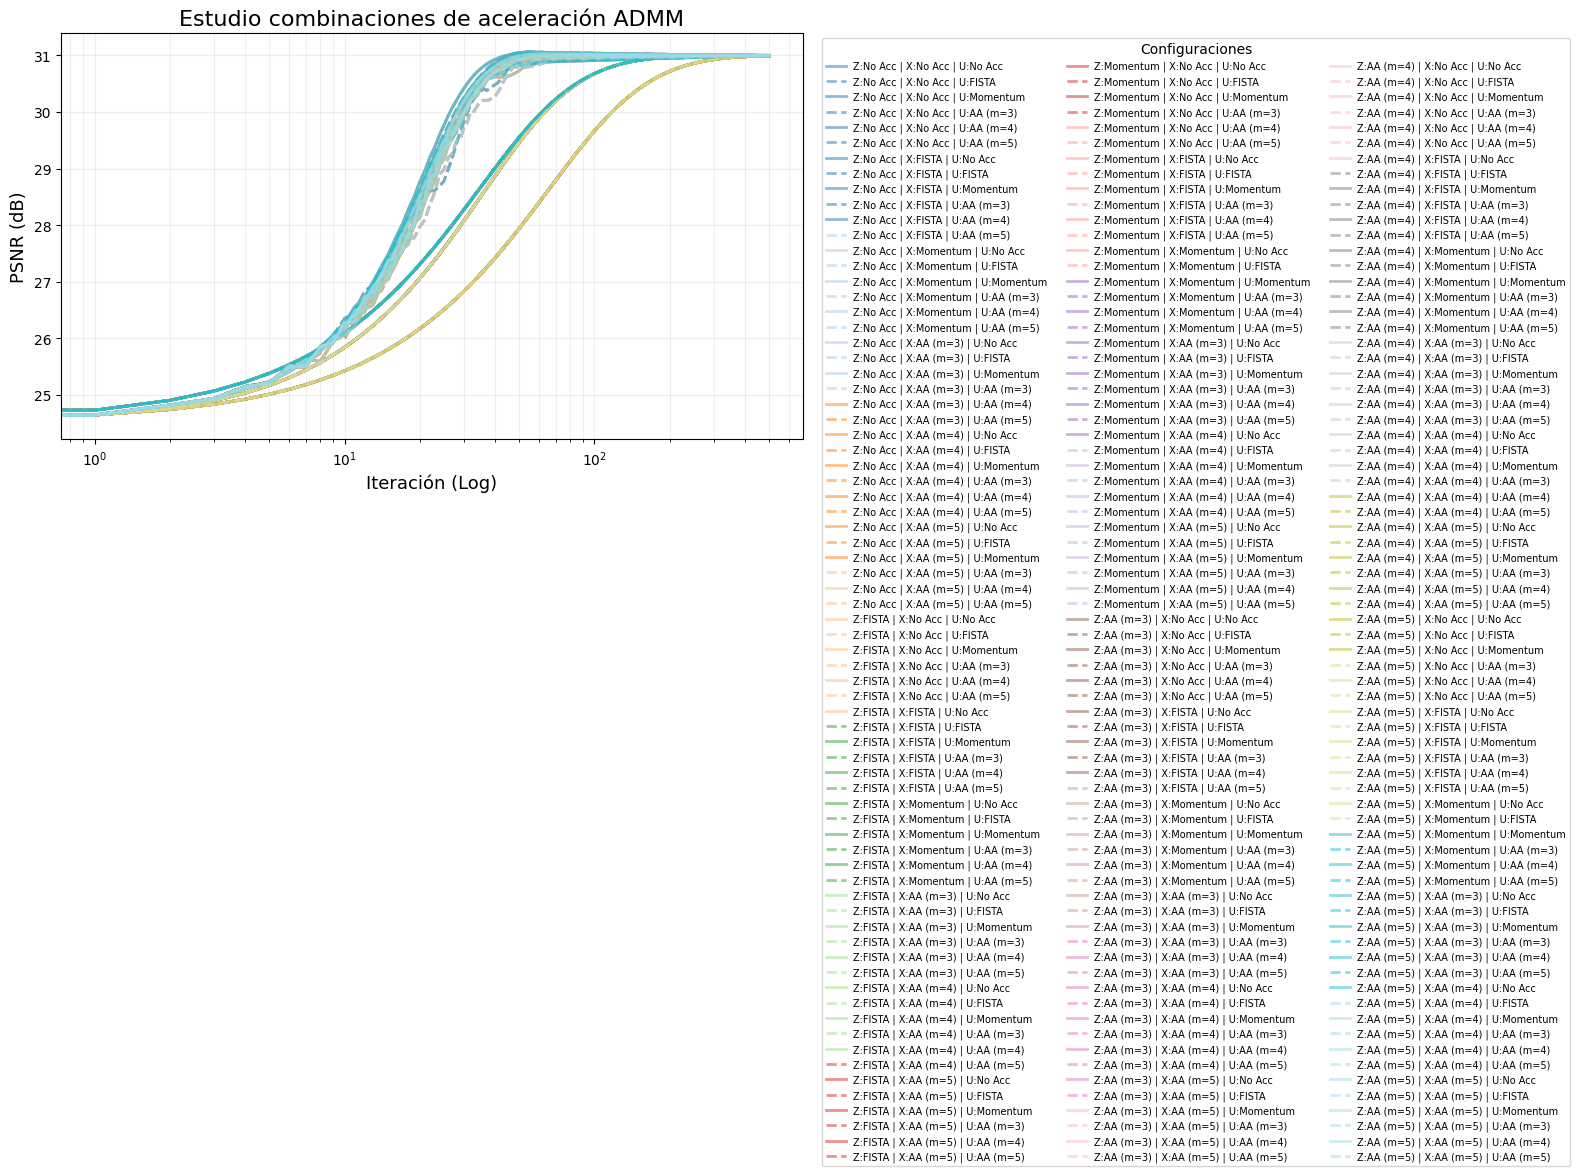

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_admm_psnr(all_results, labels):
    plt.figure(figsize=(16, 9))

    # Paleta con mucha variedad
    colors = plt.cm.get_cmap('tab20', len(all_results))

    for i, ((act_z, act_x, act_u), curve) in enumerate(all_results.items()):
        label = f"Z:{labels[act_z]} | X:{labels[act_x]} | U:{labels[act_u]}"
        print(label)
        linestyle = '-' if i % 2 == 0 else '--'

        plt.plot(curve, color=colors(i), label=label,
                 alpha=0.5, linewidth=2, linestyle=linestyle)

    plt.xscale('log')
    plt.title("Estudio combinaciones de aceleración ADMM", fontsize=16)
    plt.xlabel("Iteración (Log)", fontsize=13)
    plt.ylabel("PSNR (dB)", fontsize=13)
    plt.grid(True, which="both", ls="-", alpha=0.2)

    # REGLA DE ORO: Leyenda en múltiples columnas para que quepan las 36
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=7, ncol=3, title="Configuraciones")

    plt.tight_layout()
    plt.show()
# Ejecutar con tus datos
action_labels = {
    0: "No Acc", 1: "FISTA", 2: "Momentum", 3: "AA (m=3)", 4: "AA (m=4)", 5: "AA (m=5)"
    }
plot_admm_psnr(all_results, action_labels)

In [ ]:
def plot_admm_step_by_step(all_results, labels, vary='z', fixed_1=('x', 0), fixed_2=('u', 0)):
    """
    Argumentos:
    - all_results: Tu diccionario {(z, x, u): curve}
    - labels: El diccionario action_labels
    - vary: La variable que quieres comparar ('z', 'x', o 'u')
    - fixed_1: Tupla con (nombre_variable, valor_fijo)
    - fixed_2: Tupla con (nombre_variable, valor_fijo)
    """
    plt.figure(figsize=(12, 7))

    # Mapeo de nombres a índices en la tupla de la llave
    idx_map = {'z': 0, 'x': 1, 'u': 2}
    v_idx = idx_map[vary]
    f1_name, f1_val = fixed_1
    f2_name, f2_val = fixed_2

    # Colores consistentes para los 6 métodos
    colors = plt.cm.get_cmap('viridis', 6)

    found_any = False
    for coords, curve in all_results.items():
        # Verificamos si esta combinación cumple con los valores fijos
        if coords[idx_map[f1_name]] == f1_val and coords[idx_map[f2_name]] == f2_val:
            method_idx = coords[v_idx]
            label = f"{vary.upper()}={labels[method_idx]} (Fijos: {f1_name}={f1_val}, {f2_name}={f2_val})"

            plt.plot(curve, color=colors(method_idx), label=label, linewidth=2, alpha=0.8)
            found_any = True

    if not found_any:
        print(f"No se encontraron datos para los filtros: {vary} variando, {fixed_1}, {fixed_2}")
        return

    plt.xscale('log')
    plt.title(f"Estudio de Aceleración: Impacto de {vary.upper()}", fontsize=14)
    plt.xlabel("Iteración (Log)", fontsize=12)
    plt.ylabel("PSNR (dB)", fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3080/202732509.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', 6)


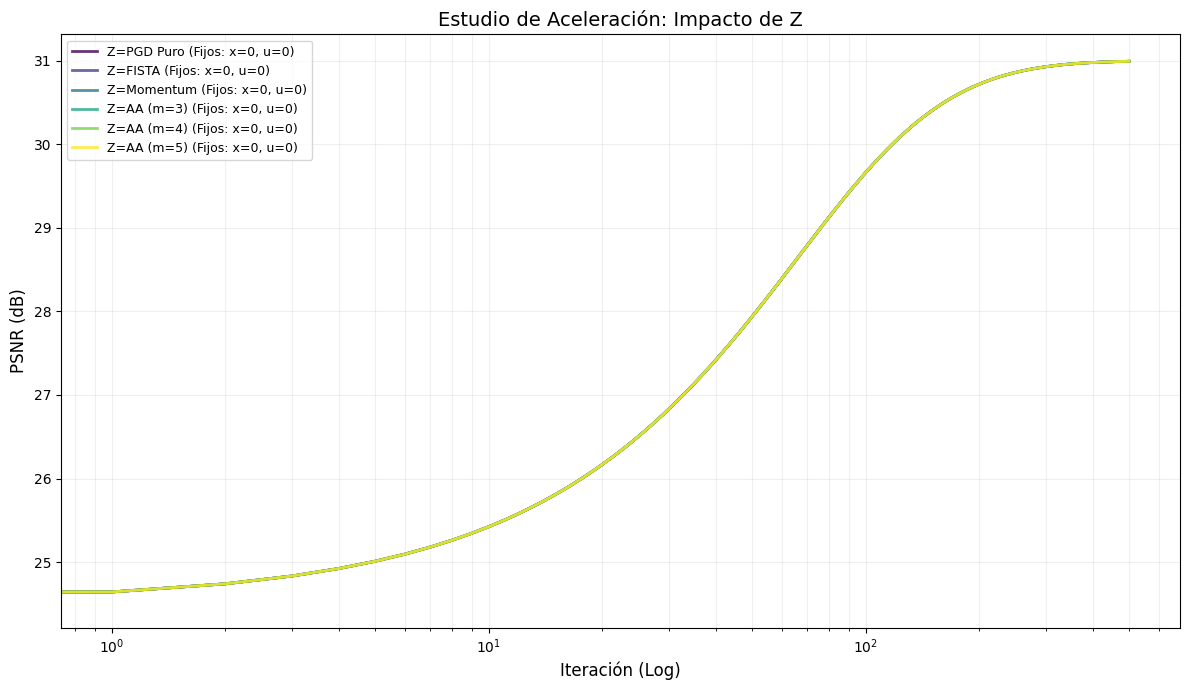

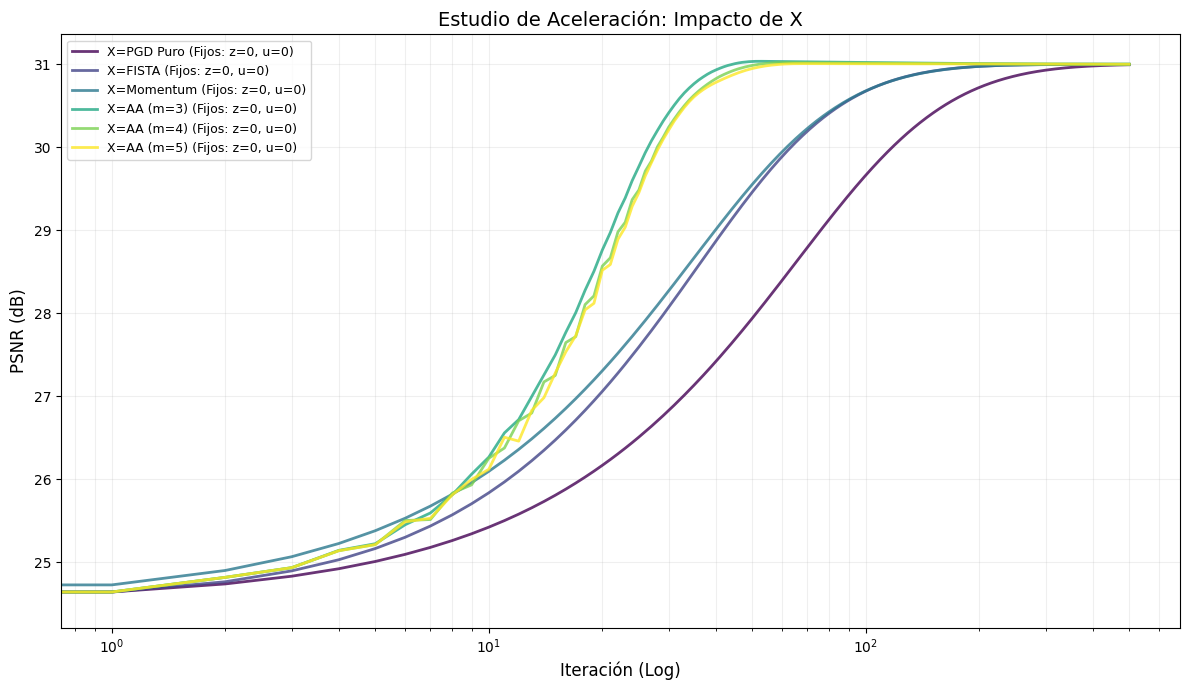

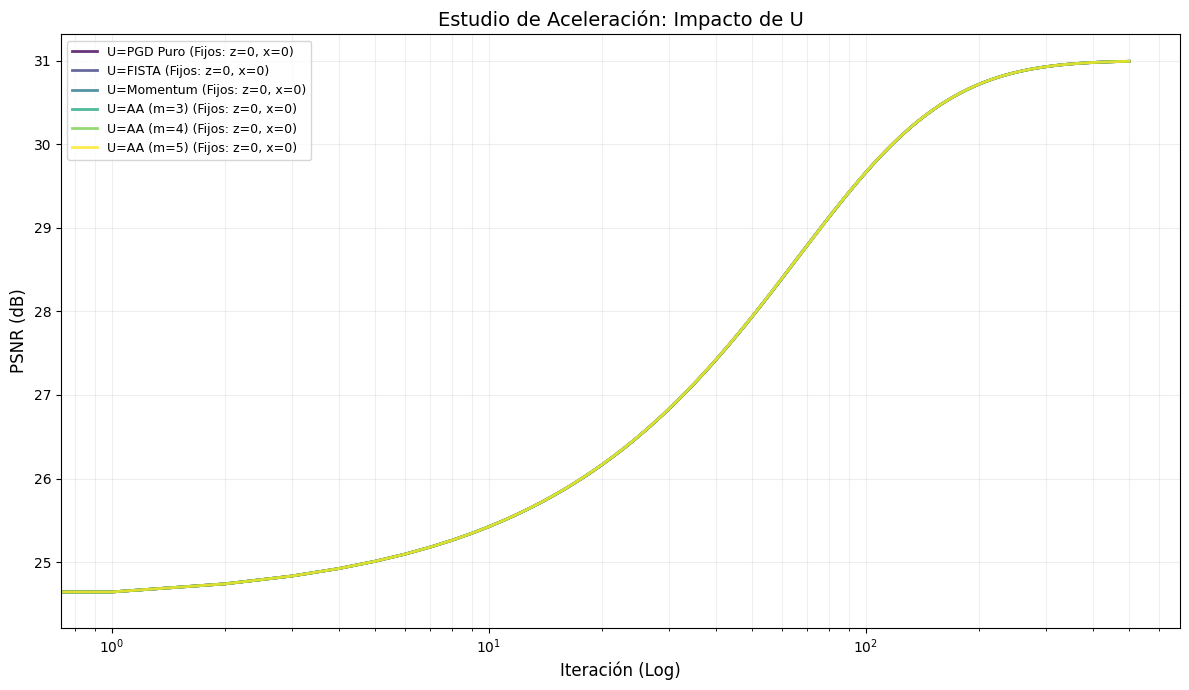

In [ ]:
# Gráfica 1: Variar Z (X y U en 0)
plot_admm_step_by_step(all_results, action_labels, vary='z', fixed_1=('x', 0), fixed_2=('u', 0))

# Gráfica 2: Variar X (Z y U en 0)
plot_admm_step_by_step(all_results, action_labels, vary='x', fixed_1=('z', 0), fixed_2=('u', 0))

# Gráfica 3: Variar U (Z y X en 0)
plot_admm_step_by_step(all_results, action_labels, vary='u', fixed_1=('z', 0), fixed_2=('x', 0))

/tmp/ipykernel_3080/204386703.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 6)


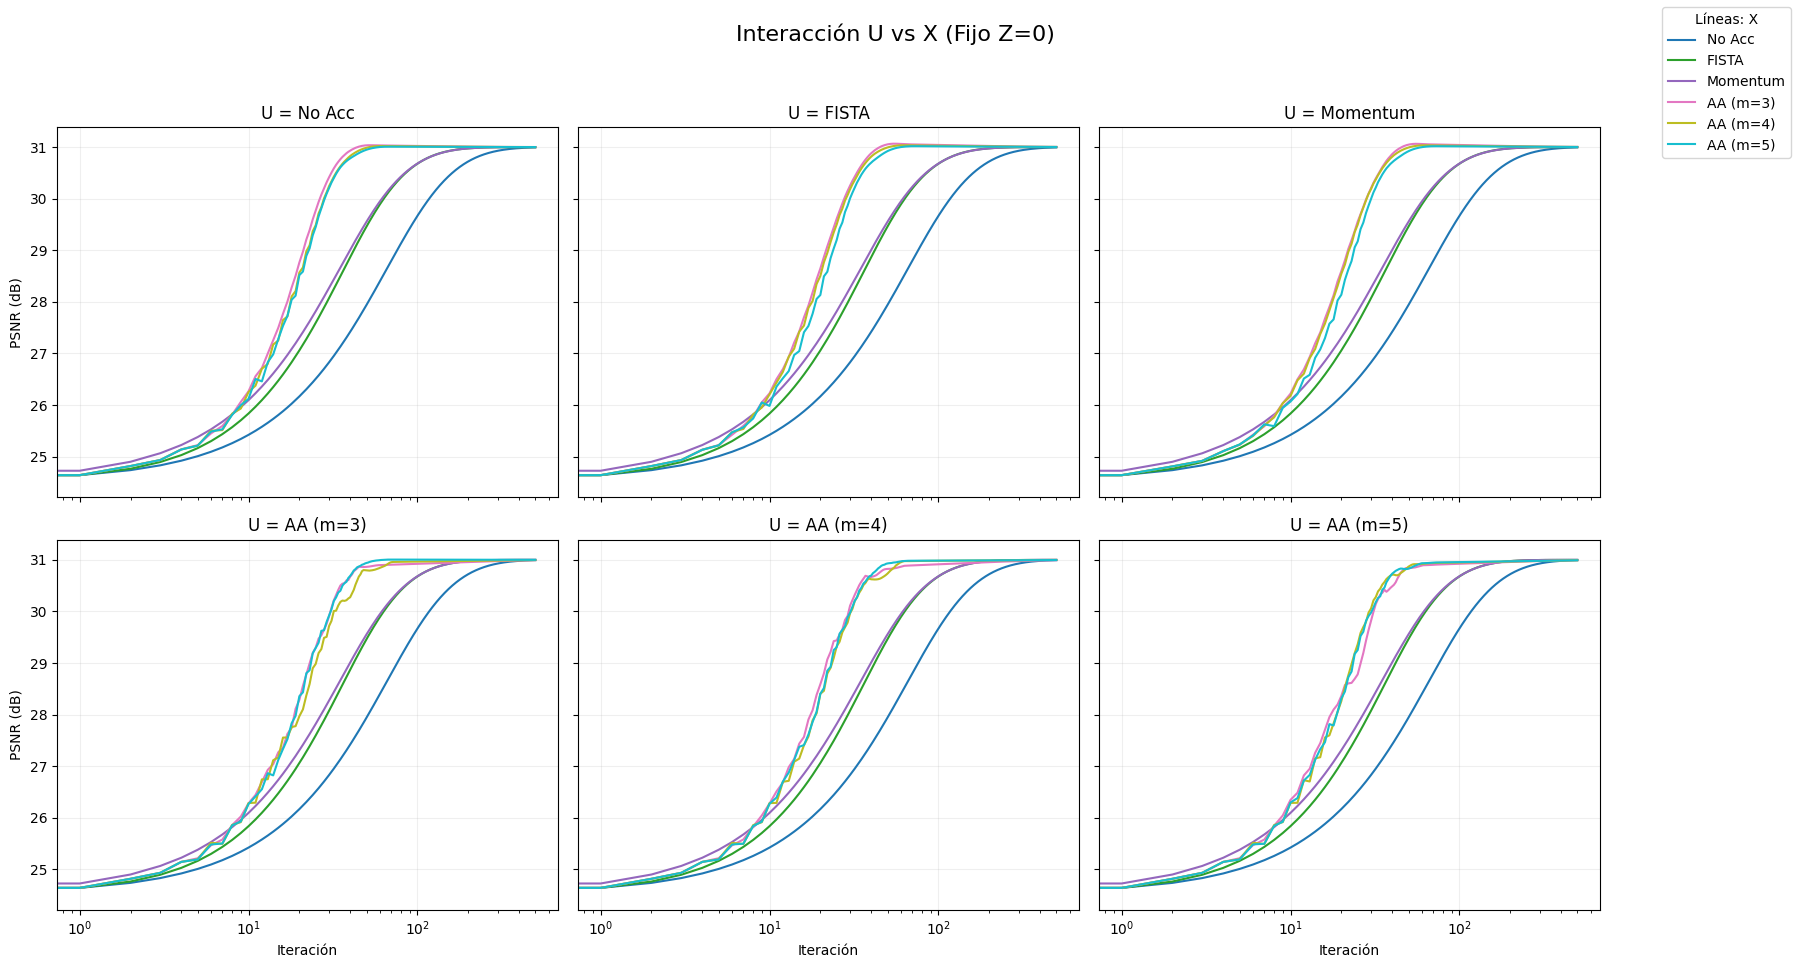

In [ ]:
def plot_dual_variation(all_results, labels, var_row='z', var_line='x', fixed_var=('u', 0)):
    """
    Crea una matriz de 2x3 gráficas para ver la interacción entre dos variables.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    idx_map = {'z': 0, 'x': 1, 'u': 2}
    f_name, f_val = fixed_var

    # Colores para las líneas (X)
    colors = plt.cm.get_cmap('tab10', 6)

    for val_row in range(6): # Iteramos sobre Z (cada sub-gráfica)
        ax = axes[val_row]
        for val_line in range(6): # Iteramos sobre X (cada línea)
            # Construir la clave para buscar en el diccionario
            coords = [0, 0, 0]
            coords[idx_map[var_row]] = val_row
            coords[idx_map[var_line]] = val_line
            coords[idx_map[f_name]] = f_val

            curve = all_results[tuple(coords)]
            ax.plot(curve, color=colors(val_line), label=labels[val_line] if val_row == 0 else "")

        ax.set_xscale('log')
        ax.set_title(f"{var_row.upper()} = {labels[val_row]}")
        ax.grid(True, alpha=0.2)
        if val_row >= 3: ax.set_xlabel("Iteración")
        if val_row % 3 == 0: ax.set_ylabel("PSNR (dB)")

    fig.suptitle(f"Interacción {var_row.upper()} vs {var_line.upper()} (Fijo {f_name.upper()}={f_val})", fontsize=16)
    fig.legend(loc='upper right', title=f"Líneas: {var_line.upper()}")
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

# Ejecución:
plot_dual_variation(all_results, action_labels, var_row='u', var_line='x', fixed_var=('z', 0))

In [ ]:
# Reconstruction Algorithm

data_fidelity = dinv.optim.L2()
denoiser = dinv.models.DnCNN(device=device, pretrained="download_lipschitz")
prior = dinv.optim.PnP(denoiser=denoiser)
stepsize = 0.1 / physics.compute_norm(physics.A_adjoint(y), tol=1e-3).item()
_lambda = 0.01

pgd = PGDStep(data_fidelity=data_fidelity, prior=prior,
              stepsize=stepsize, lambd=_lambda)

max_iter = 500

# --- Experiment ---
actions_to_test = [0, 1, 2, 3, 4, 5]
action_labels = {
    0: "PGD Puro", 1: "FISTA", 2: "Momentum", 3: "AA (m=3)", 4: "AA (m=4)", 5: "AA (m=5)"
    }

results = {action: [] for action in actions_to_test}
residual_results = {action: [] for action in actions_to_test}
fid_results = {action: [] for action in actions_to_test}

with torch.inference_mode():
  for action in actions_to_test:
    # Nueva instancia del acc para probar los aceleradores por separado
    acc = AccStep(rho=0.9, max_m=5)
    z_k = x0.clone() # Empezar siempre desde el mismo punto inicial
    x_next = x0.clone()
    desc_text = f"Action {action}: {action_labels[action]}"
    for k in tqdm(range(max_iter), desc=desc_text, colour='magenta'):
      # Paso base del optimizador
      x_old = x_next
      x_next = pgd.step(z_k, y, physics)

      # Aplicar la aceleración elegida
      z_next = acc.step(x_next, action)

      # Guardar Metrics
      results[action].append(metric(z_next, x).item())
      step_norm = torch.norm(x_next - x, p=2).item() / torch.norm(x, p=2).item()
      fidelity = data_fidelity(z_next, y, physics)
      residual_results[action].append(step_norm)
      fid_results[action].append(fidelity.item())

      z_k = z_next

Power iteration converged at iteration 2, ||A^T A||_2=1.00


Action 5: AA (m=5): 100%|██████████| 500/500 [00:13<00:00, 38.20it/s]


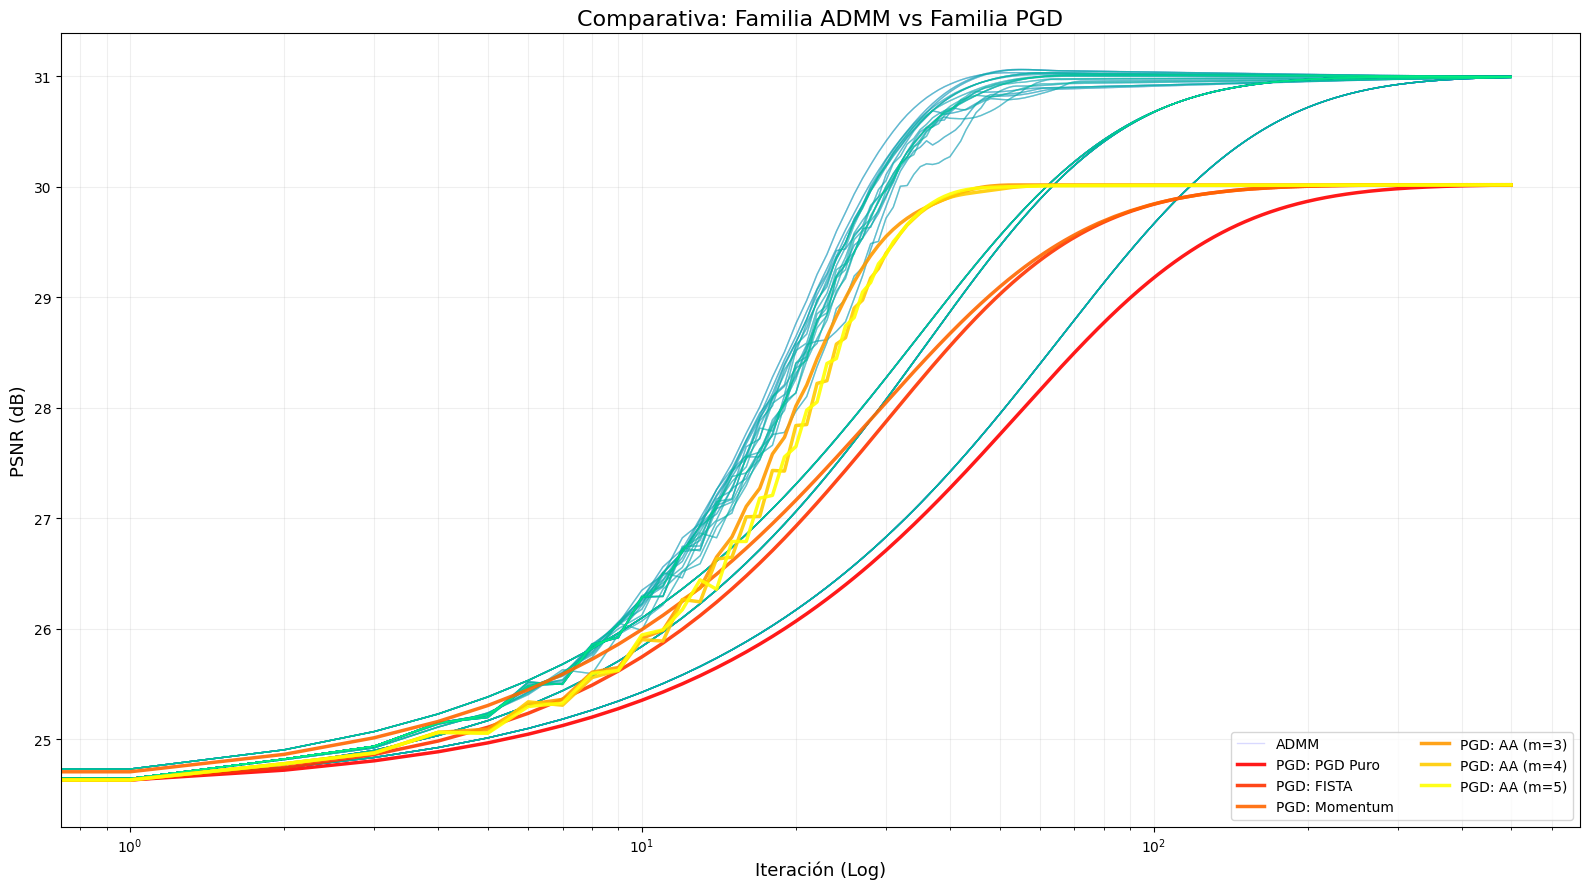

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_comparativa_admm_pgd(admm_results, pgd_results, labels):
    plt.figure(figsize=(16, 9))

    # 1. Graficar ADMM (Tonos Azules/Verdes)
    # Se usa alpha bajo para ver la densidad de las 36 combinaciones
    colors_admm = plt.cm.winter(np.linspace(0, 1, len(admm_results)))

    for i, ((act_z, act_x, act_u), curve) in enumerate(admm_results.items()):
        # Etiqueta genérica para no saturar la leyenda con 36 entradas
        lbl = "ADMM" if i == 0 else ""
        plt.plot(curve, color=colors_admm[i], alpha=0.15, linewidth=1, label=lbl)

    # 2. Graficar PGD (Tonos Rojos/Naranjas)
    # Líneas sólidas y más gruesas para distinguir la familia
    colors_pgd = plt.cm.autumn(np.linspace(0, 1, len(pgd_results)))

    for i, (action, curve) in enumerate(pgd_results.items()):
        lbl_pgd = f"PGD: {labels[action]}"
        plt.plot(curve, color=colors_pgd[i], linewidth=2.5, label=lbl_pgd, alpha=0.9)

    # Configuración de los ejes
    plt.xscale('log')
    plt.title("Comparativa: Familia ADMM vs Familia PGD", fontsize=16)
    plt.xlabel("Iteración (Log)", fontsize=13)
    plt.ylabel("PSNR (dB)", fontsize=13)
    plt.grid(True, which="both", ls="-", alpha=0.2)

    # Leyenda: Solo muestra la categoría ADMM y las 6 variantes de PGD
    plt.legend(loc='lower right', fontsize=10, ncol=2)

    plt.tight_layout()
    plt.show()

# Ejecutar
plot_comparativa_admm_pgd(all_results, results, action_labels)

In [ ]:
data_fidelity = dinv.optim.L2()
denoiser = dinv.models.DnCNN(device=device, pretrained="download_lipschitz")
prior = dinv.optim.PnP(denoiser=denoiser)
stepsize = 0.1 / physics.compute_norm(physics.A_adjoint(y), tol=1e-3).item()
rho_admm = 0.01
_lambda = 0.1
max_iter = 500

admm_step = ADMMStep(data_fidelity=data_fidelity, prior=prior, rho_admm=rho_admm, lambd=_lambda)
psnr_base = []

# Inicialización de variables
x_k = x0.clone()
z_k = x0.clone()
u_k = x0.clone()

with torch.inference_mode():
    pbar = tqdm(range(max_iter), desc="Ejecutando ADMM Base", colour='blue')
    for k in pbar:

        z_next, x_next, u_next = admm_step.step(z_k, x_k, u_k, y, physics)

        x_k = x_next
        z_k = z_next
        u_k = u_next

        current_psnr = metric(x_k, x).item()
        psnr_base.append(current_psnr)

        pbar.set_postfix({"PSNR": f"{current_psnr:.2f}"})

print(f"ADMM Base finalizado. PSNR Final: {psnr_base[-1]:.4f}")

Power iteration converged at iteration 2, ||A^T A||_2=1.00


Ejecutando ADMM Base: 100%|██████████| 500/500 [00:13<00:00, 38.30it/s, PSNR=29.31]

ADMM Base finalizado. PSNR Final: 29.3116


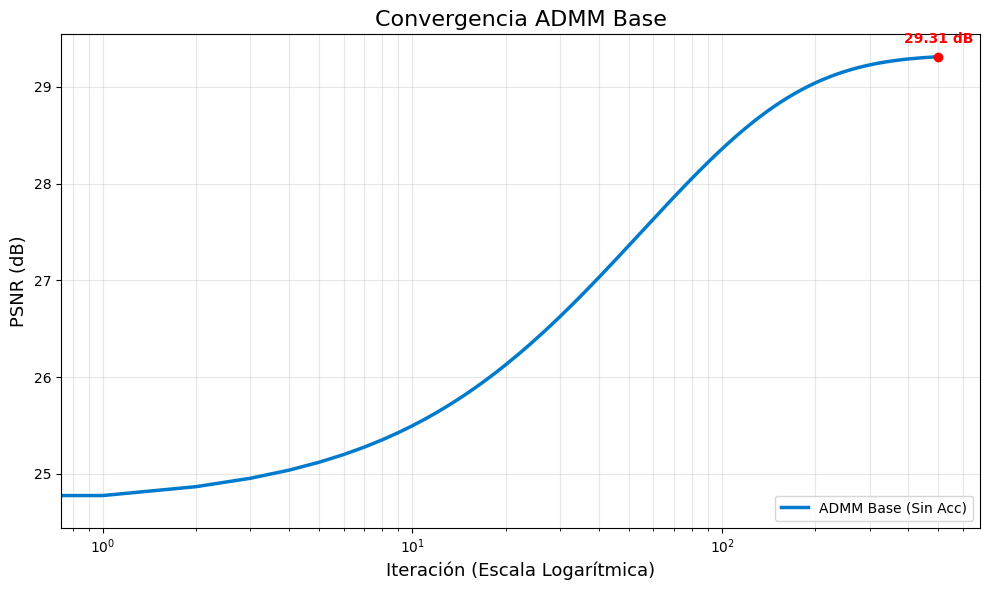

In [ ]:
import matplotlib.pyplot as plt

def plot_admm_base(psnr_values):
    plt.figure(figsize=(10, 6))

    # Graficamos la curva base
    plt.plot(psnr_values, color='#007acc', linewidth=2.5, label='ADMM Base (Sin Acc)')

    # Configuración de escalas
    plt.xscale('log')
    plt.yscale('linear')

    # Estética y Etiquetas
    plt.title("Convergencia ADMM Base", fontsize=16)
    plt.xlabel("Iteración (Escala Logarítmica)", fontsize=13)
    plt.ylabel("PSNR (dB)", fontsize=13)

    # Rejilla detallada
    plt.grid(True, which="both", ls="-", alpha=0.3)

    # Punto final (Marcador de PSNR final)
    plt.scatter(len(psnr_values)-1, psnr_values[-1], color='red', zorder=5)
    plt.annotate(f'{psnr_values[-1]:.2f} dB',
                 (len(psnr_values)-1, psnr_values[-1]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontsize=10,
                 color='red',
                 fontweight='bold')

    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()

# Ejecutar con tu lista psnr_base
plot_admm_base(psnr_base)

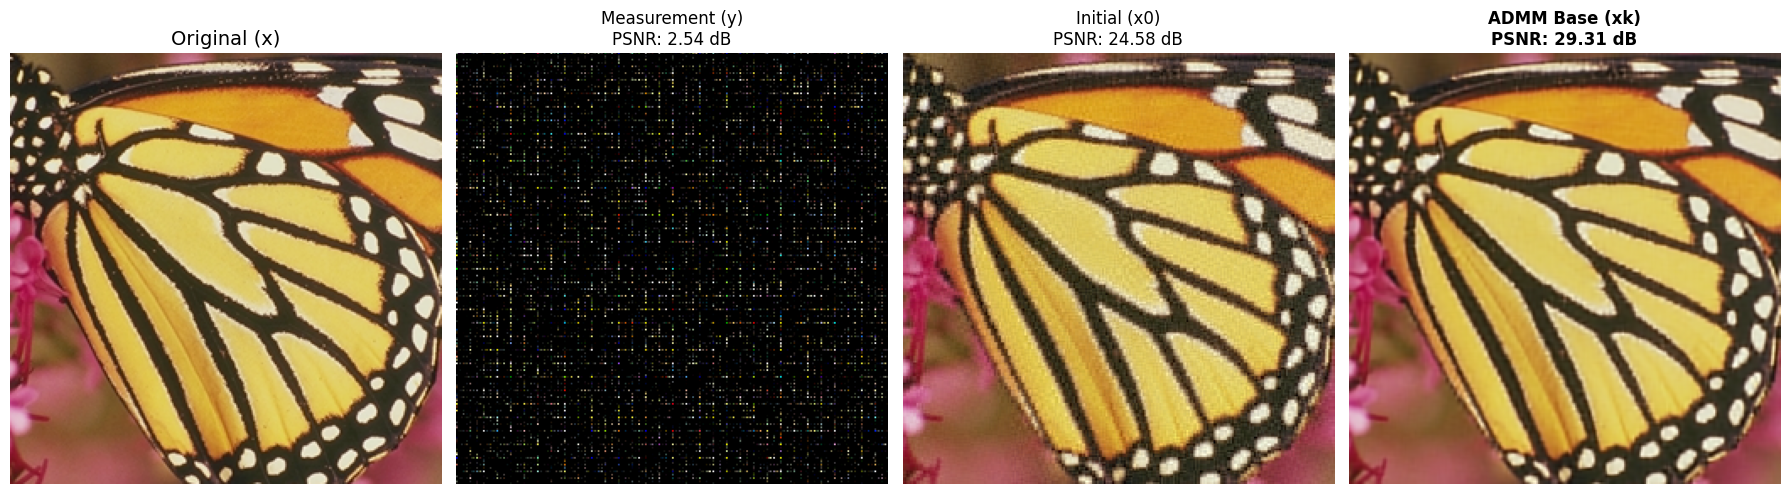

In [ ]:
import matplotlib.pyplot as plt

# Asegúrate de extraer x_final del diccionario X si usaste el iterador de deepinv

plt.figure(figsize=(18, 5)) # Un poco más ancho para que no se amontonen

# 1. Imagen Original (Ground Truth)
plt.subplot(1, 4, 1)
plt.imshow(x.cpu().detach().squeeze(0).permute(1, 2, 0).clip(0, 1))
plt.title('Original (x)', fontsize=14)
plt.axis('off')

# 2. Mediciones (y) - El dato ruidoso o degradado
plt.subplot(1, 4, 2)
# Nota: y puede tener dimensiones distintas según la física (SPC, Inpainting, etc.)
# Si y es visualizable como imagen, usamos este:
plt.imshow(y.cpu().detach().squeeze(0).permute(1, 2, 0).clip(0, 1))
plt.title(f'Measurement (y)\nPSNR: {metric(y, x).item():.2f} dB', fontsize=12)
plt.axis('off')

# 3. Inicialización (x0) - Suele ser el Adjoint A^T(y)
plt.subplot(1, 4, 3)
plt.imshow(x0.cpu().detach().squeeze(0).permute(1, 2, 0).clip(0, 1))
plt.title(f'Initial (x0)\nPSNR: {metric(x0, x).item():.2f} dB', fontsize=12)
plt.axis('off')

# 4. Resultado Final ADMM (xk)
plt.subplot(1, 4, 4)
plt.imshow(x_k.cpu().detach().squeeze(0).permute(1, 2, 0).clip(0, 1))
plt.title(f'ADMM Base (xk)\nPSNR: {metric(x_k, x).item():.2f} dB', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

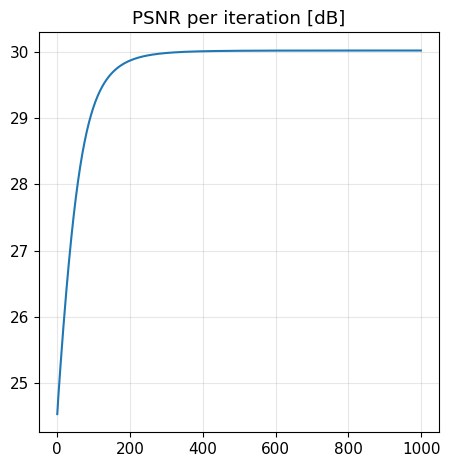

In [ ]:
plt.figure()
plt.plot(PSNRs)
plt.title(f'PSNR per iteration [dB]')
plt.gca().set_box_aspect(1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()